In [1]:
import pandas as pd
import numpy as np

In [3]:
X = pd.read_csv("Voitures.csv",delimiter=";", index_col=0)


X

,puissance,Longueur,Hauteur,poids,CO2,Origine,Carburant,4X4
Modele,,,,,,,,
Alfasud TI,75,421,149,1217,143,Europe,Diesel,non
Audi 100,138,426,146,1381,142,France,Diesel,non
Simca 1300,204,491,145,1723,223,France,Diesel,non
Citroen GS Club,150,486,158,1735,188,France,Diesel,non
Fiat 132,61,367,147,932,141,France,Essence,non
Lancia Beta,340,502,148,1835,291,Autre,Essence,non
Peugeot 504,102,421,143,1205,168,Europe,Essence,non
Renault 16 TL,202,455,167,1595,237,Autre,Diesel,oui
Renault 30,223,429,154,1595,235,Autre,Essence,non


In [4]:
X.dtypes

puissance     int64
Longueur      int64
Hauteur       int64
poids         int64
CO2           int64
Origine      object
Carburant    object
4X4          object
dtype: object

In [23]:
import numpy as np

X1 = X.select_dtypes(exclude=['object'])

X2 = X.select_dtypes(include=[object])

X1.head()
columns_names=X1.columns
columns_names

Index(['puissance', 'Longueur', 'Hauteur', 'poids', 'CO2'], dtype='object')

In [6]:
X1.isnull().sum()


puissance    0
Longueur     0
Hauteur      0
poids        0
CO2          0
dtype: int64

In [7]:
# On regarde maintenant les données continues: corrélations et distributions

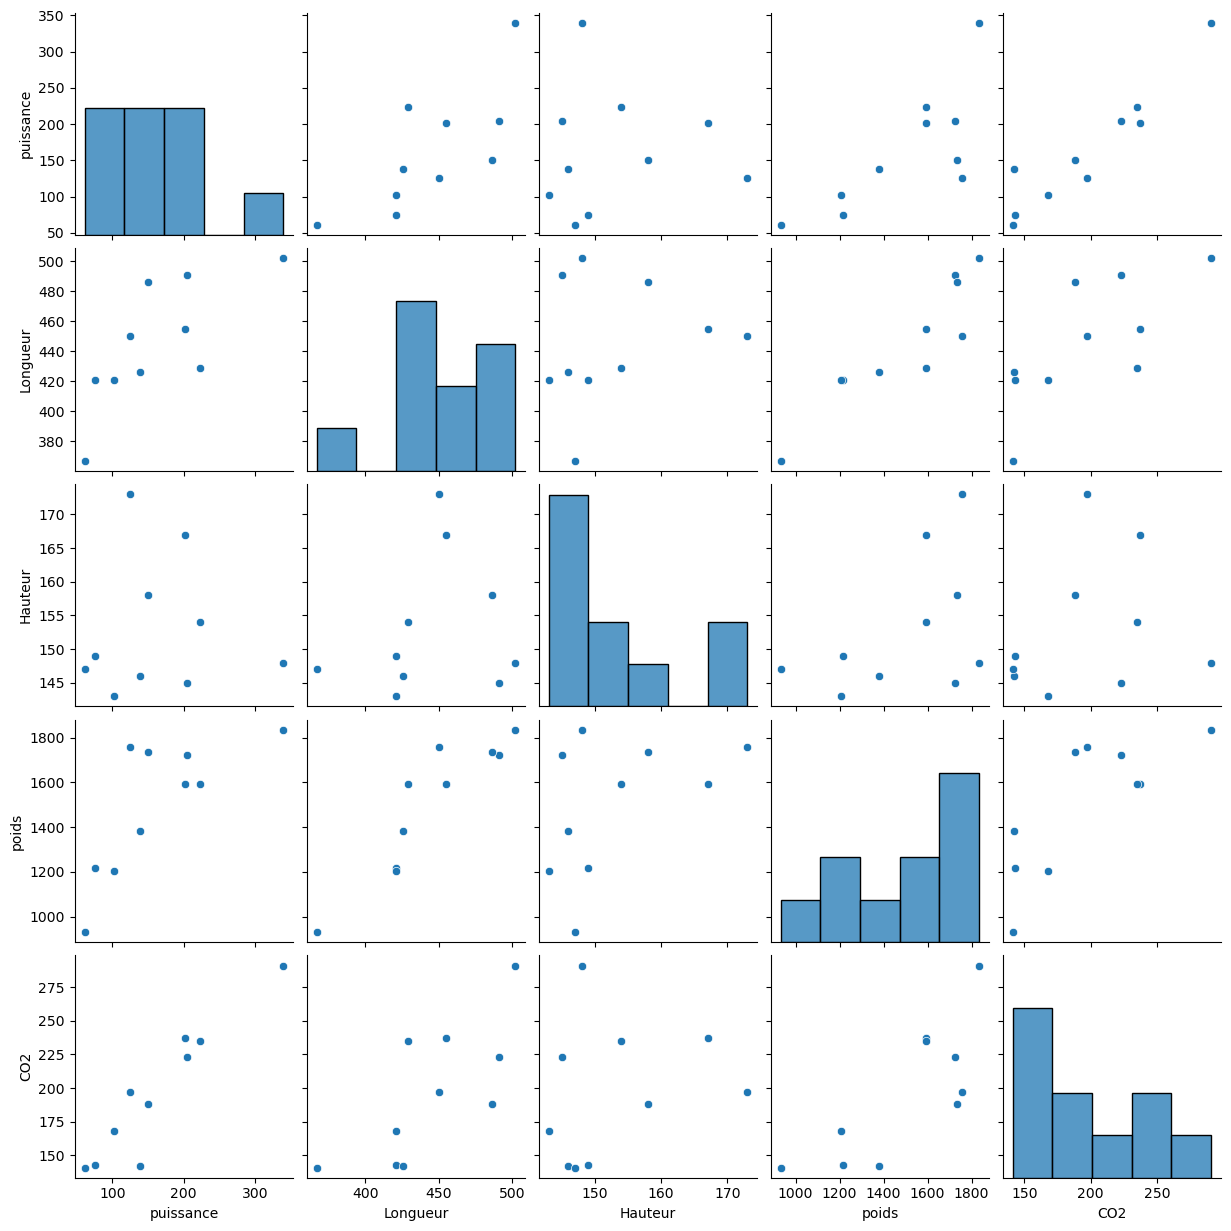

In [8]:
import seaborn as sns
sns.pairplot(X1)

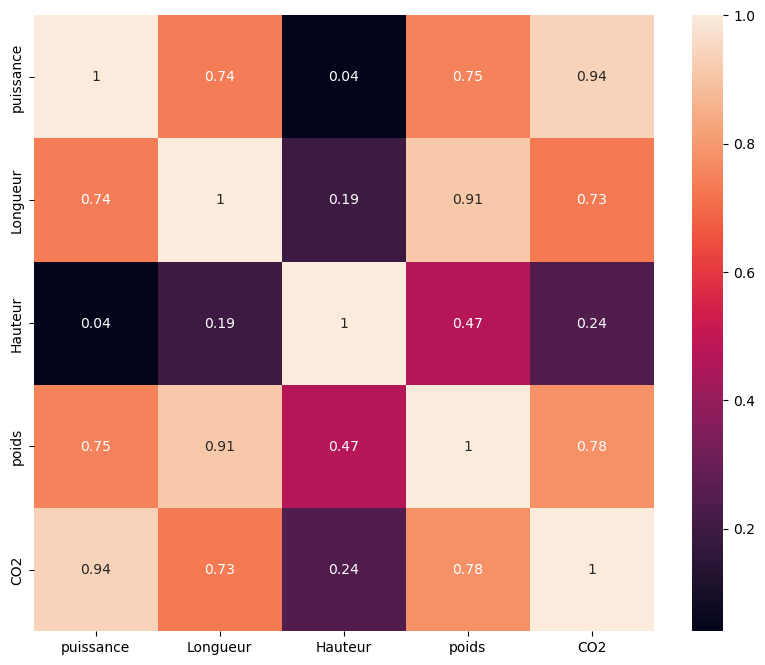

In [9]:
import matplotlib.pyplot as plt


corr=X1.corr()
corr=corr.round(2)
f,ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.show()

In [10]:
# on va transformer les distributions et créer un dataset X2

In [25]:
import numpy as np 
from sklearn.preprocessing import PowerTransformer
YJ = PowerTransformer(method='yeo-johnson', standardize=True)
X3 = YJ.fit_transform(X1)
X3=pd.DataFrame(data=X3,columns=X1.columns, index=X1.index)
X3


,puissance,Longueur,Hauteur,poids,CO2
Modele,,,,,
Alfasud TI,-1.292182,-0.653670,-0.282528,-1.081895,-1.232365
Audi 100,-0.110998,-0.530694,-0.753407,-0.593826,-1.264837
Simca 1300,0.691165,1.227913,-0.941759,0.807021,0.674476
Citroen GS Club,0.057134,1.081991,0.753407,0.866453,-0.024484
Fiat 132,-1.673359,-1.871992,-0.596447,-1.688411,-1.297616
Lancia Beta,1.794316,1.555255,-0.439487,1.390801,1.686251
Peugeot 504,-0.707116,-0.653670,-1.318462,-1.113377,-0.507573
Renault 16 TL,0.670505,0.217036,1.475422,0.217952,0.914101
Renault 30,0.878954,-0.456073,0.345311,0.217952,0.881046


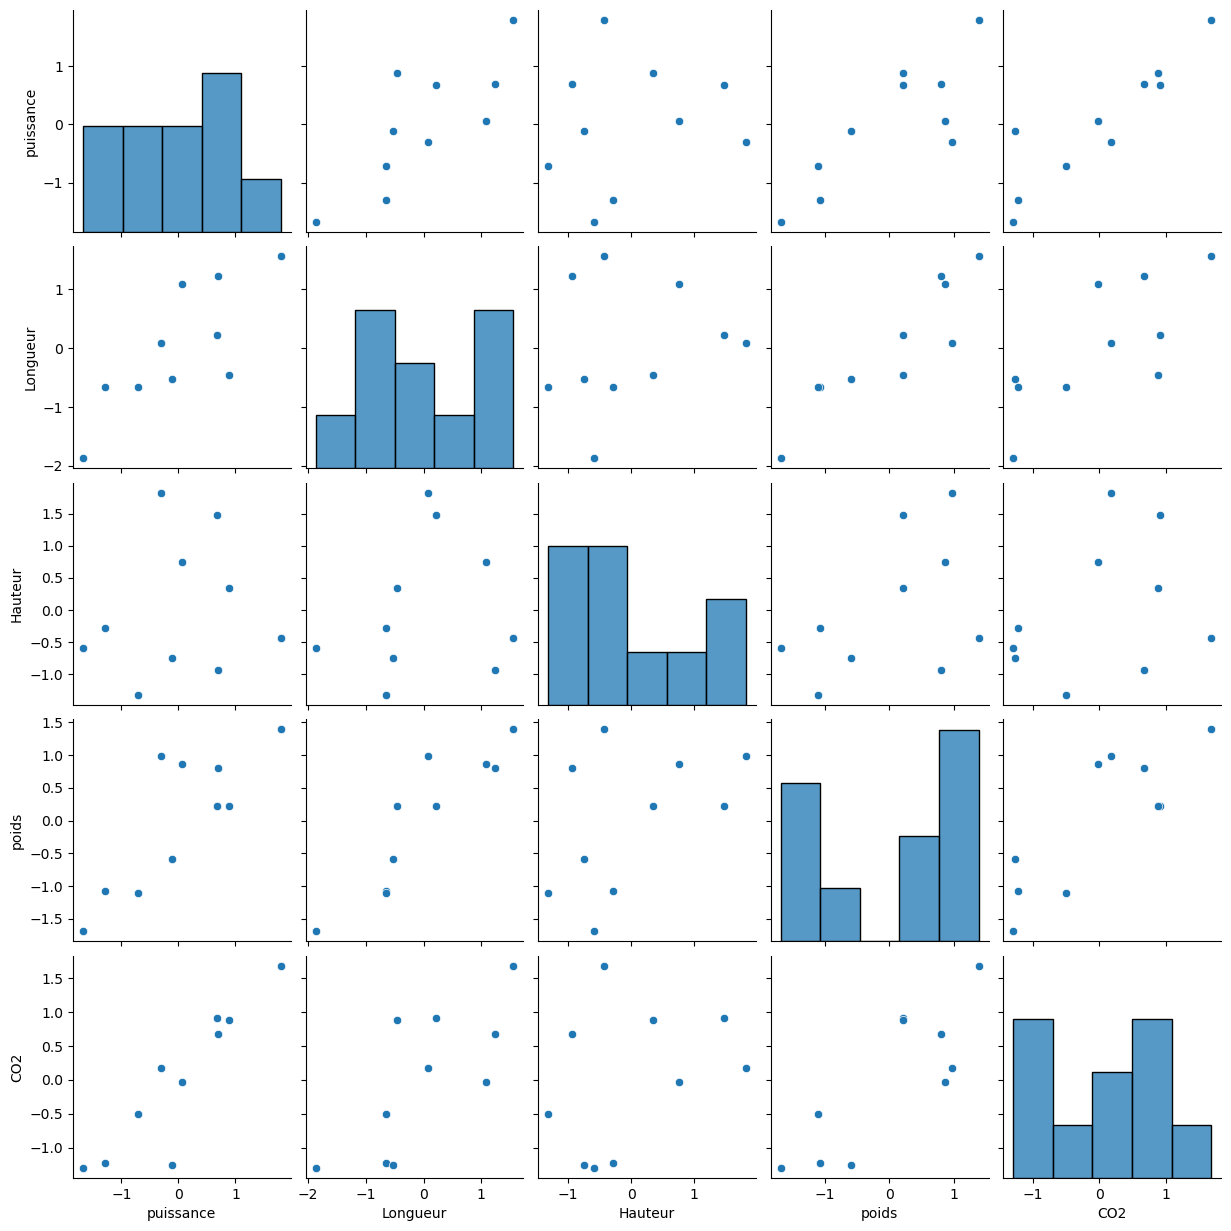

In [27]:
sns.pairplot(X3)

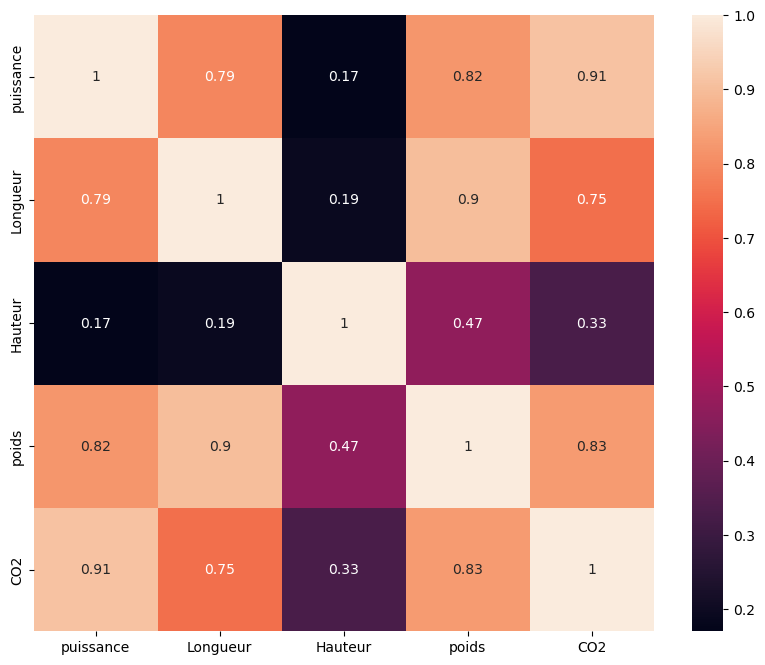

In [28]:
corr2=X3.corr()
corr2=corr2.round(2)
f,ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr2,annot=True)

plt.show()

In [29]:
#Standardiser les données de X1

In [30]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Z = StandardScaler().fit_transform(X1)
Z1 = pd.DataFrame(data = Z, columns = X1.columns,index=X1.index)
Z1.head()

,puissance,Longueur,Hauteur,poids,CO2
Modele,,,,,
Alfasud TI,-1.102875,-0.614031,-0.418854,-0.988562,-1.126565
Audi 100,-0.304241,-0.485033,-0.732994,-0.410579,-1.147623
Simca 1300,0.532422,1.191942,-0.837708,0.794727,0.558018
Citroen GS Club,-0.152121,1.062944,0.523567,0.837018,-0.178987
Fiat 132,-1.280349,-2.007209,-0.628281,-1.992984,-1.168680


In [31]:
#vérification moyennes et déviations standards

In [32]:
import numpy
print(numpy.mean(Z1,axis=0))


puissance   -1.665335e-17
Longueur    -2.692291e-16
Hauteur     -4.440892e-17
poids        0.000000e+00
CO2          8.673617e-18
dtype: float64


In [33]:
print(numpy.std(Z1,axis=0,ddof=0))

puissance    1.0
Longueur     1.0
Hauteur      1.0
poids        1.0
CO2          1.0
dtype: float64


In [34]:
import sklearn as sk

In [35]:
from sklearn.decomposition import PCA

In [36]:
print(PCA)

<class 'sklearn.decomposition._pca.PCA'>


In [37]:
acp=PCA(svd_solver='full')
print(acp)

PCA(svd_solver='full')


In [38]:
coord1=acp.fit_transform(X1)

In [39]:
print(coord1)

[[-2.97823530e+02 -2.87074242e+01  1.17883390e+01  5.35444603e+00
   1.82583915e+00]
 [-1.26479621e+02 -1.58076711e+01  1.67870923e+01 -3.13730237e+01
   2.80892162e+00]
 [ 2.34508876e+02 -6.73991296e+00  1.87773030e+01  8.86451829e+00
  -6.62827555e+00]
 [ 2.29737257e+02 -7.26755291e+01  1.64495360e+01  3.18788557e+00
   1.80282920e+00]
 [-5.81553169e+02  2.83494066e+01 -1.21589975e+01  2.17291585e+00
  -2.16552683e-02]
 [ 3.80964670e+02  1.12121234e+02  1.04300945e+01  1.56001613e-01
   1.81055955e+00]
 [-3.00527249e+02  9.01981723e+00  7.72450430e+00  1.27471576e+01
  -3.84674575e+00]
 [ 1.08826354e+02  2.72242461e+01 -1.55033768e+01  1.22588968e+01
   8.45989490e+00]
 [ 1.09666515e+02  4.46733153e+01 -2.70028144e+01 -1.32377527e+01
  -5.77063273e+00]
 [ 2.42679896e+02 -9.74574821e+01 -2.72916805e+01 -1.31045283e-01
  -4.40735119e-01]]


In [40]:
print(acp.explained_variance_ratio_)

[9.59216675e-01 3.54284788e-02 3.39421555e-03 1.76020854e-03
 2.00421887e-04]


In [41]:
coordZ=acp.fit_transform(Z1)
print(coordZ)

[[-1.96277298e+00 -4.04334794e-04  3.70543815e-01 -1.39846369e-01
   7.66359671e-02]
 [-1.29200712e+00 -4.53816515e-01  4.27635687e-01  5.03978042e-01
   1.96508292e-01]
 [ 1.35346593e+00 -9.63396984e-01  7.34488720e-01 -1.15067309e-01
  -1.90288457e-01]
 [ 8.72156584e-01  6.22253504e-01  1.00352190e+00 -4.34444122e-02
   5.42943726e-02]
 [-3.28853199e+00 -2.02460964e-01 -7.33477549e-01 -8.52714047e-02
  -4.81271052e-03]
 [ 3.28710863e+00 -1.38537146e+00 -4.20872871e-01 -3.32594176e-02
   1.24451153e-01]
 [-1.67614493e+00 -7.65341057e-01  9.27966462e-02 -2.41224191e-01
  -1.13368250e-01]
 [ 1.23973574e+00  1.10139722e+00 -6.81391115e-01 -2.48036157e-01
   2.12209182e-01]
 [ 7.70083524e-01 -1.74481076e-01 -8.88778867e-01  3.01911327e-01
  -2.14147965e-01]
 [ 6.96906613e-01  2.22162167e+00  9.55336378e-02  1.00259890e-01
  -1.41481583e-01]]


In [42]:
print(acp.explained_variance_ratio_)

[0.70317854 0.20492793 0.07707576 0.01035939 0.00445838]


In [43]:
# On a 90% de la variance expliquée sur 2 axes

In [44]:
# Les Valeurs propres
eigval = acp.explained_variance_
print([eigval])

[array([3.90654745, 1.13848851, 0.42819864, 0.05755219, 0.02476877])]


In [45]:
#On a les 2 premières VP >1 

#On va regarder l'évolution des VP en fonction des composantes principales

5
[0 1 2 3 4]
[3.90654745 1.13848851 0.42819864 0.05755219 0.02476877]


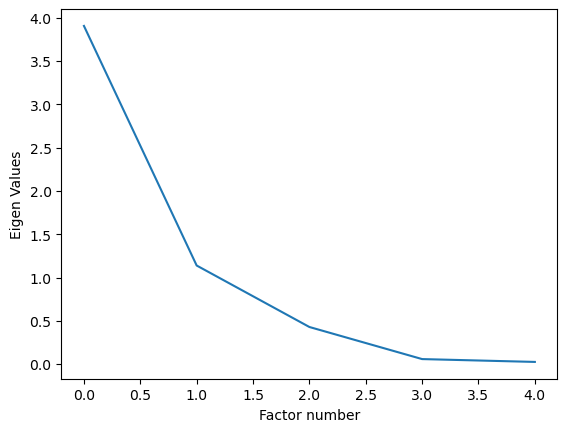

In [46]:
#nombre de variables
p = X1.shape[1]
print(p)
nunu=np.arange(p)
print(nunu)
print(eigval)
#nombre d'observations
n = X1.shape[0]
#matrice des X
X = X1.values

import matplotlib.pyplot as plt
plt.plot(np.arange(5),eigval)
plt.ylabel("Eigen Values")
plt.xlabel("Factor number")
plt.show()

In [65]:
#Seuils à appliquer (si non visuel)
p = X1.shape[1]
bs = 1/numpy.arange(p,0,-1)
bs = numpy.cumsum(bs)
# on fait 1/5 + 1/4 + 1/3 + 1/2 + 1
bs = bs[::-1]

array([0.2       , 0.45      , 0.78333333, 1.28333333, 2.28333333])

In [64]:
print(pd.DataFrame({'Val.Propre':eigval,'Seuils':bs}))

   Val.Propre    Seuils
0    3.906547  2.283333
1    1.138489  1.283333
2    0.428199  0.783333
3    0.057552  0.450000
4    0.024769  0.200000


In [159]:
# On va regarder sur 2 CP (90% déjà de variance expliquée) 

acp=PCA(n_components=2,svd_solver='full')
coord=acp.fit_transform(Z)
print(coord)

[[-1.96277298e+00 -4.04334794e-04]
 [-1.29200712e+00 -4.53816515e-01]
 [ 1.35346593e+00 -9.63396984e-01]
 [ 8.72156584e-01  6.22253504e-01]
 [-3.28853199e+00 -2.02460964e-01]
 [ 3.28710863e+00 -1.38537146e+00]
 [-1.67614493e+00 -7.65341057e-01]
 [ 1.23973574e+00  1.10139722e+00]
 [ 7.70083524e-01 -1.74481076e-01]
 [ 6.96906613e-01  2.22162167e+00]]


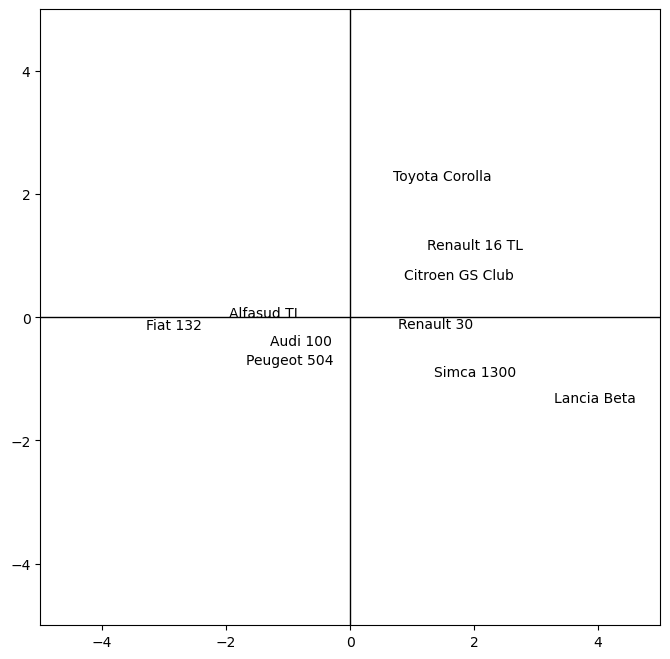

In [160]:
f,ax = plt.subplots(figsize=(8,8))
#fig, axes = plt.plot(figsize=(10,10))
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
n = X1.shape[0]
for i in range(n):
    plt.annotate(X1.index[i],(coord[i,0],coord[i,1]))
plt.plot([-5,5],[0,0],color='black',linestyle='-',linewidth=1)
plt.plot([0,0],[-5,5],color='black',linestyle='-',linewidth=1)
plt.show()

In [161]:
# Calculs des cos2

In [162]:
di = numpy.sum(Z**2,axis=1)
print(pd.DataFrame({'ID':X1.index,'d_i':di}))

                ID        d_i
0       Alfasud TI   4.015211
1         Audi 100   2.350713
2       Simca 1300   3.348928
3  Citroen GS Club   2.159748
4         Fiat 132  11.400717
5      Lancia Beta  12.918066
6      Peugeot 504   3.474861
7    Renault 16 TL   3.320869
8       Renault 30   1.550410
9   Toyota Corolla   5.460477


In [163]:
#F2/d2 pour un axe (F de l'axe)= cos2= qualité de la représentation de la voiture sur l'axe

In [169]:
cos2 = coord**2
for j in range(2):
    cos2[:,j] = cos2[:,j]/di
print(pd.DataFrame({'ID':X1.index,'COS2_1':cos2[:,0],'COS2_2':cos2[:,1]}))

                ID    COS2_1        COS2_2
0       Alfasud TI  0.959471  4.071682e-08
1         Audi 100  0.710117  8.761146e-02
2       Simca 1300  0.547002  2.771436e-01
3  Citroen GS Club  0.352197  1.792799e-01
4         Fiat 132  0.948576  3.595427e-03
5      Lancia Beta  0.836432  1.485713e-01
6      Peugeot 504  0.808510  1.685670e-01
7    Renault 16 TL  0.462814  3.652887e-01
8       Renault 30  0.382498  1.963587e-02
9   Toyota Corolla  0.088944  9.038775e-01


In [ ]:
#Calcul des contributions des individus aux axes

In [170]:
ctr = coord**2
for j in range(2):
 ctr[:,j] = ctr[:,j]/(n*eigval[j])
 
print(pd.DataFrame({'id':X1.index,'CTR_1':ctr[:,0],'CTR_2':ctr[:,1]}))

                id     CTR_1         CTR_2
0       Alfasud TI  0.098616  1.435997e-08
1         Audi 100  0.042730  1.808972e-02
2       Simca 1300  0.046892  8.152333e-02
3  Citroen GS Club  0.019471  3.400995e-02
4         Fiat 132  0.276829  3.600426e-03
5      Lancia Beta  0.276589  1.685791e-01
6      Peugeot 504  0.071917  5.144953e-02
7    Renault 16 TL  0.039343  1.065514e-01
8       Renault 30  0.015180  2.674041e-03
9   Toyota Corolla  0.012432  4.335224e-01


In [171]:
print(numpy.sum(ctr,axis=0))

[0.9 0.9]


In [ ]:
#Ce n'est pas égale à 1 car perte d'information sur 2 axes seulement

In [ ]:
# Poids des variables initiales sur les axes

In [172]:
#On lance l'ACP avec toutes les composantes:
acp=PCA(svd_solver='full')
coord=acp.fit_transform(Z)

#racine carrée des valeurs propres
sqrt_eigval = numpy.sqrt(eigval)

#corrélation des variables avec les axes
corvar = numpy.zeros((p,p))
for k in range(p):
 corvar[:,k] = acp.components_[k,:] * sqrt_eigval[k]
 
#afficher la matrice des corrélations variables x facteurs 
print(corvar)

[[ 0.95261236 -0.35116438 -0.24775666  0.10398575  0.09015533]
 [ 0.95336284 -0.08077027  0.42401807 -0.11421623  0.05338457]
 [ 0.36820487  0.97559575 -0.14711798 -0.01650766  0.04281378]
 [ 1.00042786  0.19127907  0.21991925  0.13559774 -0.08316435]
 [ 0.97659906 -0.14238505 -0.3420757  -0.12261548 -0.07100381]]


In [173]:
#on affiche pour les deux premiers axes
print(pd.DataFrame({'id':X1.columns,'COR_1':corvar[:,0],'COR_2':corvar[:,1]}))

          id     COR_1     COR_2
0  puissance  0.952612 -0.351164
1   Longueur  0.953363 -0.080770
2    Hauteur  0.368205  0.975596
3      poids  1.000428  0.191279
4        CO2  0.976599 -0.142385


In [35]:
#Quelles sont les variables qui distinguent ces voitures?
#Comment projeter de nouvelles voitures?



In [ ]:
# dataset supplémentaire: voitures_supp.csv

# On va centrer et réduire les variables supplémentaires AVEC LES PARAMETRES moy ET Sigma des données initiales


Supp= pd.read_csv("voitures_supp.csv", header=0, index_col=0)
ZSupp=sc.transform(Supp)
print(ZSupp)

In [41]:
#On calcule les coordonnées des voitures supplémentaires

CoordSupp=acp.transform(ZSupp)

# On les représente dans les 2 1ers axes factoriels
fig, axes = plt.subplots(figsize=(12,12))
axes.set_xlim(-6,6)
axes.set_ylim(-6,6)
#étiquette des points actifs
for i in range(n):
 plt.annotate(X.index[i],(coord[i,0],coord[i,1]))
 
#étiquette des points supplémentaires (illustratifs) en bleu ‘b’
for i in range(coordSupp.shape[0]):
 plt.annotate(indSupp.index[i],(coordSupp[i,0],coordSupp[i,1]),color='b')
 
#ajouter les axes
plt.plot([-6,6],[0,0],color='silver',linestyle='-',linewidth=1)
plt.plot([0,0],[-6,6],color='silver',linestyle='-',linewidth=1)
#affichage
plt.show()


array([[-1.17308591, -1.00826206, -0.28823982, -1.07106492, -1.17746518,
        -0.01207264,  1.00142416,  0.88509766,  0.84519496,  0.54599063,
         0.97962953,  0.27680892],
       [-0.61815519, -0.57725334, -0.34030223, -0.6550553 , -0.65457143,
         0.21068898,  0.796304  ,  0.80737789,  0.7340277 ,  0.68214217,
         1.02160899,  0.19285001],
       [ 0.68607766,  0.47155628, -0.31576616,  0.39335887,  0.60095868,
         0.79827232,  0.2697389 ,  0.59213231,  0.53338877,  0.92787367,
         1.05611908,  0.12382982],
       [ 0.15521161,  0.18148616,  0.2352887 ,  0.23657686,  0.19148122,
         0.80367565,  0.31419002,  0.55529728,  0.84663255,  0.54422996,
         0.79705394,  0.6419601 ],
       [-1.28913517, -1.25750238, -0.92973157, -1.47196876, -1.40491444,
        -0.34304245,  1.24185416,  1.04605778,  0.59916496,  0.84731462,
         1.25575791, -0.27544784],
       [ 2.14512029,  1.58101068, -0.55010724,  1.440252  ,  1.95812611,
         1.34148135, -